# Part 1 - Distributed Data Processing with Spark

In [2]:
from pathlib import Path
import requests
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
from openai import OpenAI
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

In [ ]:
# Define URL for required file
taxi_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"

# Create data/raw directory if it doesn't exist
BASE_DIR = Path.cwd().resolve()
data_dir = BASE_DIR / "data" / "raw"
data_dir.mkdir(parents=True, exist_ok=True)

# Defines File path for downloaded data
taxi_path = data_dir / "yellow_tripdata_2024-01.parquet"

# Download File and write to specified path
def download_file(url, path):
    if path.exists():
        return
     
    with requests.get(url, stream=True, timeout=30) as r:
        r.raise_for_status()
        with open(path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

download_file(taxi_url, taxi_path)
print("\nFile downloaded successfully!")

In [ ]:
# Creating a Spark Session
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("LLM-Powered Applications & Distributed Computing") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Verifying the session creation
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

In [ ]:
# Load the parquet file into a Spark Dataframe
df = spark.read.parquet(str(taxi_path))

# Display the schema: Column names and types
df.printSchema()

# Verify the first 5 rows of data
df.show(5, truncate=True)

# Display total number of rows
print(f"\nTotal number of rows: {df.count():,}")

# Display total number of columns
print(f"Total number of columns: {len(df.columns)}")

# Display total number of partitions
print(f"Total number of partitions: {df.rdd.getNumPartitions()}")

In [ ]:
# Timing for Reading Data with Spark
start = time.time()
df_spark = spark.read.parquet(str(taxi_path))
spark_read_time = time.time() - start

# Timing for Compution with Spark
start = time.time()
spark_count = df_spark.count()
spark_action_time = time.time() - start

# Timing for Reading Data with Pandas
start = time.time()
df_pandas = pd.read_parquet(str(taxi_path))
pandas_read_time = time.time() - start

# Display Results
print(f"Spark schema read (lazy): {spark_read_time:.3f}s")
print(f"Spark count action: {spark_action_time:.3f}s ({spark_count:,} rows)")
print(f"Pandas full read: {pandas_read_time:.3f}s ({len(df_pandas):,} rows)")
print(f"Pandas memory usage: {df_pandas.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Cleaning up Pandas Dataframe
del df_pandas

The Spark load time is seen to be much faster because it is lazy meaning that just the metadata is being loaded with no actual data. Upon conducting an action using Spark, the data would then be loaded hence the time result seen for the Spark count action. In contrast, Pandas is much slower due to the full dataset being loaded into memory immediately.

In [ ]:
# Remove rows with nulls in critical columns
def remove_nulls(df_spark):
    initial_count = df_spark.count()

    df_spark = df_spark.dropna(subset=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_distance",
        "PULocationID",
        "DOLocationID",
        "fare_amount"
    ])
    removed_count = initial_count - df_spark.count()
    print(f"Removed {removed_count:,} rows with null values.")
    return df_spark

# Filtering out invalid trips
def filter_trips(df_spark):
    initial_count = df_spark.count()

    df_spark = df_spark.filter(
        (F.col("trip_distance") > 0) &
        (F.col("fare_amount") > 0) &
        (F.col("fare_amount") <= 500) &
        (F.col("tpep_dropoff_datetime") >= F.col("tpep_pickup_datetime"))
    )
    removed_count = initial_count - df_spark.count()
    print(f"Removed {removed_count:,} rows with invalid trip data.")
    return df_spark

df_spark = remove_nulls(df_spark)
df_spark = filter_trips(df_spark)
print(f"\nRemaining rows after cleaning: {df_spark.count():,}")

In [ ]:
def create_derived_columns(df_spark):
    df_spark = df_spark.withColumns({
        "trip_duration_minutes": (
            F.unix_timestamp("tpep_dropoff_datetime") -
            F.unix_timestamp("tpep_pickup_datetime")
        ) / 60,

        "pickup_hour": F.hour("tpep_pickup_datetime"),

        "pickup_day_of_week": F.date_format("tpep_pickup_datetime", "EEEE"),

        "tip_percentage": F.when(
            F.col("fare_amount") > 0,
            (F.col("tip_amount") / F.col("fare_amount")) * 100
        ).otherwise(0)
    })

    df_spark = df_spark.withColumn(
        "trip_speed_mph",
        F.when(
            F.col("trip_duration_minutes") > 0,
            F.col("trip_distance") / (F.col("trip_duration_minutes") / 60)
        ).otherwise(0)
    )

    return df_spark

df_spark = create_derived_columns(df_spark)
print("\nDerived columns created successfully!\n")
df_spark.show(5, truncate=True)

In [ ]:
# Register as a temporary view for SQL queries
df_spark.createOrReplaceTempView("taxi_trips")

In [ ]:
# Query 1: Top 10 Busiest Pickup Hours
busiest_hours = spark.sql("""
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY trip_count DESC
    LIMIT 10
""")

print("Top 10 Busiest Pickup Hours:")
busiest_hours.show()

From the results above, it can be seen that taxi demand peaks in the late afternoon from around 3pm to 7pm, with 6pm being the busiest hour, likely reflecting commuting patterns and increased activity after work hours. During these hours, fares remain relatively steady while tip percentages are consistently high being around 20-23% suggesting strong rider demand and possibly heavier traffic or longer trips.

In [ ]:
# Query 2: Day with Highest Average Trip Speed
fastest_day = spark.sql("""
    SELECT
        pickup_day_of_week,
        ROUND(AVG(trip_speed_mph), 2) AS avg_speed,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(trip_duration_minutes), 2) AS avg_duration
    FROM taxi_trips
    GROUP BY pickup_day_of_week
    ORDER BY avg_speed DESC
    LIMIT 1
""")

print("Day with Highest Average Trip Speed:")
fastest_day.show()

From the result above, Tuesday was found to have the highest average trip speed, suggesting smoother traffic conditions and less congestion compared to other days. Despite moderate trip distances and durations, the higher speed indicates more efficient travel, likely due to lower demand or lighter traffic flow.

In [ ]:
# Query 3: Top 5 Pickup Locations by Total Revenue for Each Day of the Week
daily_location_revenue = df_spark.groupBy(
    "pickup_day_of_week", "PULocationID"
    ).agg(
        F.sum("fare_amount").alias("total_revenue")
    )

day_window = Window.partitionBy("pickup_day_of_week").orderBy(F.desc("total_revenue"))

ranked_locations = daily_location_revenue.withColumn(
    "rank", F.rank().over(day_window)
)

top_locations = ranked_locations.filter(F.col("rank") <= 5)

top_5_locations = top_locations.orderBy("pickup_day_of_week", F.desc("total_revenue"))

print("Top 5 Pickup Locations by Total Revenue for Each Day of the Week:")
top_5_locations.show(top_5_locations.count(), truncate=False)

From the above rankings, we can determine that pickup location 132 consistently generates the highest revenue across all days of the week, indicating it is a major hotspot for taxi activity and likely a high-demand area. Additionally, a small group of locations such as 138, 161 and 237 frequently appear in the top rankings suggesting that revenue is concentrated in a few key areas rather that being evenly distributed.

In [ ]:
# Query 4: Day when Cumulative Trip Count by Hour of the Day Surpasses 50% of Daily Trips
hourly_trips = df_spark.groupBy("pickup_hour").agg(
    F.count("*").alias("trips_per_hour")
).orderBy("pickup_hour")

cumulative_window = Window.orderBy("pickup_hour") \
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)

total_window = Window.partitionBy()

hourly_cumulative = hourly_trips \
    .withColumn("cumulative_trips",
        F.sum("trips_per_hour").over(cumulative_window)
    ) \
    .withColumn("cumulative_fraction", 
        F.round(
            F.col("cumulative_trips") / F.sum("trips_per_hour").over(total_window), 2)
    )

print("Cumulative Trip Count By Hour of the Day:")
hourly_cumulative.show(24)

hour_surpassed_50 = hourly_cumulative \
    .filter(F.col("cumulative_fraction") >= 0.5) \
    .orderBy("pickup_hour") \
    .limit(1)

print("Hour when Cumulative Trip Count Surpasses 50% of Daily Trips:")
hour_surpassed_50.select("pickup_hour").show()

From the above results, we can interpret that trip activity builds steadily throughout the day with demand accelerating from the morning and reaching over 50% of total daily trips by 3pm, indicating that the majority of trips occur in the afternoon and evening. This pattern highlights a strong concentration of travel during peak daytime hours, likely driven by work-related movement and early evening activities.  

In [ ]:
# Query 5: Comparison of Average Fare, Distance an Tip Percentage between Short, Medium, and Long Trips
trip_comparison = spark.sql("""
    WITH categorized AS (
        SELECT
            CASE
                WHEN trip_distance < 2 THEN "Short (<2 miles)"
                WHEN trip_distance <= 10 THEN "Medium (2-10 miles)"
                ELSE "Long (>10 miles)"
            END AS distance_category,
            fare_amount,
            trip_distance,
            tip_percentage
        FROM taxi_trips
    ),
    aggregated AS (
        SELECT
            distance_category,
            COUNT(*) AS trip_count,
            ROUND(AVG(fare_amount), 2) AS avg_fare,
            ROUND(AVG(trip_distance), 2) AS avg_distance,
            ROUND(AVG(tip_percentage), 2) AS avg_tip_percentage
        FROM categorized
        GROUP BY distance_category
    )
    SELECT *,
        RANK() OVER (ORDER BY avg_tip_percentage DESC) AS tip_rank
    FROM aggregated
    ORDER BY avg_tip_percentage DESC
""")

print("Comparison of Average Fare, Distance and Tip Percentage between Short, Medium, and Long Trips:")
trip_comparison.show()

From the results above, short trips (<2 miles) have the highest tip percentage despite having the lowest fares, suggesting passengers tend to tip more generously on quick, low-cost rides. In contrast, long trips generate the highest fares but slightly lower tip percentages, while medium trips show the lowest tipping behaviour overall, indicating that tipping does not scale directly with trip distance or cost.

In [ ]:
# Function to simulate repeated workload
def multi_query(df_spark):
    q1 = df_spark.groupBy("pickup_hour").agg(F.avg("fare_amount")).count()
    q2 = df_spark.groupBy("PULocationID").agg(F.sum("total_amount")).count()
    q3 = df_spark.filter(F.col("trip_distance") > 10).count()
    return q1, q2, q3

# Warm-up run
df_spark.count()

# Baseline timings (no caching)
no_cache_times = []
for i in range(3):
    start = time.time()
    multi_query(df_spark)
    no_cache_times.append(time.time() - start)

no_cache_avg = sum(no_cache_times) / len(no_cache_times)
print(f"\nAverage execution time over 3 runs without caching: {no_cache_avg:.3f}s")

# Cache Dataframe
df_spark.cache()

# First run with caching
start = time.time()
multi_query(df_spark)
cache_first = time.time() - start
print(f"First execution time with caching: {cache_first:.3f}s")

# Remaining runs with caching
cache_times = []
for i in range(3):
    start = time.time()
    multi_query(df_spark)
    cache_times.append(time.time() - start)

cache_avg = sum(cache_times) / len(cache_times)
print(f"Average execution time over 3 runs with caching: {cache_avg:.3f}s")

print(f"\nPerformance improvement with caching: {no_cache_avg / cache_avg:.2f}x faster on average")

In [ ]:
# Create output directory for cleaned, partitioned data
output_dir = BASE_DIR / "data" / "output"
output_dir.mkdir(parents=True, exist_ok=True)

# Repartition DataFrame by pickup hour for optimized writes
df_partitioned = df_spark.repartition(24, "pickup_hour")

# Write cleaned DataFrame to Parquet, partitioned by pickup hour
df_partitioned.write \
    .mode("overwrite") \
    .partitionBy("pickup_hour") \
    .parquet(str(output_dir))

# Inspect partitions
for item in sorted(os.listdir(str(output_dir))):
    if item.startswith("pickup_hour"):
        print(item)

In [ ]:
# Read partitioned data
df_partitioned = spark.read.parquet(str(output_dir))

# Query only hour 17 data
hour_17 = df_partitioned.filter(F.col("pickup_hour") == 17)

# Check execution plan
print("\nExecution plan:")
hour_17.explain(mode="formatted")

# Benchmark
start = time.time()
hour_17.count()
partitioned_time = time.time() - start

start = time.time()
df_spark.filter(F.col("pickup_hour") == 17).count()
full_scan_time = time.time() - start

print(f"\nExecution time with partition pruning: {partitioned_time:.3f}s")
print(f"Execution time without partition pruning: {full_scan_time:.3f}s")
print(f"Performance improvement with partition pruning: {full_scan_time / partitioned_time:.2f}x faster")

In [ ]:
# Physical plan for Query 1: Top 10 Busiest Pickup Hours
print("\nPhysical plan for Query 1: Top 10 Busiest Pickup Hours")
busiest_hours.explain(mode="formatted")

The above physical plan for Query 1 shows how spark executes the query in stages. The Scan parquet operation reads the raw taxi data from storage and the Filter operation removes invalid records based on conditions such as no null values and positive fare and trip distance. The HashAggregate operation groups data by pickup_hour and computes metrics such as trip count and average fare, while the Exchange operation redistributes data across partitions to enable correct aggregation.

In [ ]:
# Closing Spark Session
spark.stop()
print("\nSpark session closed successfully!")

# Part 2: RAG Pipeline over Transportation Documents

In [3]:
# Specify the directory containing PDFs
BASE_DIR = Path.cwd().resolve()
docs_dir = BASE_DIR / "docs"

# Load PDFs from the specified directory
loader = PyPDFDirectoryLoader(str(docs_dir))
raw_documents = loader.load()

# Calculate total pages and characters
total_pages = len(raw_documents)
total_chars = sum(len(doc.page_content) for doc in raw_documents)

print(f"Loaded {total_pages} pages from all PDFs")
print(f"Total characters in all PDFs: {total_chars}")

print(f"\nFirst document metadata: {raw_documents[0].metadata}")
print(f"First 200 chars: {raw_documents[0].page_content[:200]}")

c:\Users\jm201\AppData\Local\Programs\Python\Python311\Lib\site-packages\pypdf\_crypt_providers\_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


Loaded 186 pages from all PDFs
Total characters in all PDFs: 404707

First document metadata: {'source': 'C:\\dev\\LLM Project\\LLM-Powered-Applications-and-Distributed-Computing\\docs\\2023 Annual Report.pdf', 'page': 0}
First 200 chars: MTA OIG Annual Report 
1
2023 Annual Report
Office of the MTA Inspector General



In [4]:
# Identify short pages (less than 50 characters)
short_pages = []
for doc in raw_documents:
    if len(doc.page_content.strip()) < 50:
        short_pages.append(doc.metadata)

# Function to identify garbled text based on character composition
def is_garbled(text):
    if not text.strip():
        return True
    alpha_ratio = sum(c.isalpha() for c in text) / len(text)
    space_ratio = sum(c.isspace() for c in text) / len(text)
    return alpha_ratio < 0.3 and space_ratio < 0.5

# Identify garbled pages based on the first 200 characters
garbled_pages = []
for doc in raw_documents:
    if is_garbled(doc.page_content[:200]):
        garbled_pages.append(doc.metadata)

print(f"Number of short pages: {len(short_pages)}")
print(f"Number of garbled pages: {len(garbled_pages)}")

Number of short pages: 13
Number of garbled pages: 3


In [5]:
def create_chunks(chunk_size):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=200,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    return text_splitter.split_documents(raw_documents)

# Split the documents into chunks
chunks = create_chunks(chunk_size=1000)

# Ensure metadata is preserved in chunks
for chunk in chunks:
    chunk.metadata["source"] = chunk.metadata.get("source", "unknown_file")
    chunk.metadata["page"] = chunk.metadata.get("page", "unknown_page")

print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 186 pages into 574 chunks


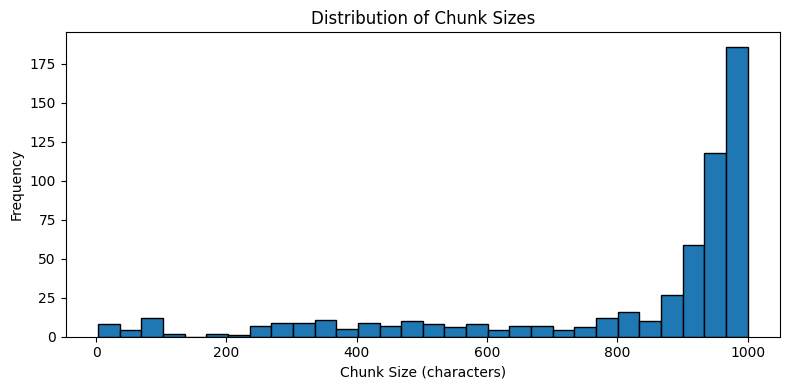

In [6]:
# Visualize the distribution of chunk sizes
chunk_lengths = [len(chunk.page_content) for chunk in chunks]

plt.figure(figsize=(8, 4))
plt.hist(chunk_lengths, bins=30, edgecolor='black')
plt.title("Distribution of Chunk Sizes")
plt.xlabel("Chunk Size (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
# Initialize HuggingFace Embeddings
embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

# Test embedding
test_embedding = embedding_model.embed_query("What is machine learning?")
print(f"Embedding dimension: {len(test_embedding)}")
print(f"First 5 values: {test_embedding[:5]}")

c:\Users\jm201\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_core\_api\deprecation.py:141: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 0.3.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  warn_deprecated(
c:\Users\jm201\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding dimension: 384
First 5 values: [-0.01995457336306572, 0.00987803004682064, 0.010249663144350052, 0.029553668573498726, 0.027186430990695953]


In [8]:
# Create ChromaDB vector store and index the chunks
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="NYC-RAG-Pipeline"
)

print(f"Indexed {len(chunks)} chunks in ChromaDB")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Indexed 574 chunks in ChromaDB


In [9]:
# Create different chunk sizes for experimentation
chunks_500 = create_chunks(chunk_size=500)
chunks_2000 = create_chunks(chunk_size=2000)

# Create separate vector stores for each chunk size
vectorstore_500 = Chroma.from_documents(
    documents=chunks_500,
    embedding=embedding_model,
    collection_name="ChunkSize-500-Experiment"
)

vectorstore_2000 = Chroma.from_documents(
    documents=chunks_2000,
    embedding=embedding_model,
    collection_name="ChunkSize-2000-Experiment"
)

# Define a set of queries to test retrieval performance
queries = [
    "What are the main transportation policies?",
    "How is public transit funded?",
    "What challenges affect transporation systems?"
]

# Function to retrieve results from the vector store
def retrieve_results(vectorstore, query):
    return vectorstore.similarity_search(query, k=3)

# Retrieve and print results for each query across different chunk sizes
for query in queries:
    print(f"\nQuery: {query}")
    
    results_500 = retrieve_results(vectorstore_500, query)
    for i, doc in enumerate(results_500):
        print(f"{i+1}. {doc.page_content[:150]}...\n")
    
    results_1000 = retrieve_results(vectorstore, query)
    for i, doc in enumerate(results_1000):
        print(f"{i+1}. {doc.page_content[:150]}...\n")

    results_2000 = retrieve_results(vectorstore_2000, query)
    for i, doc in enumerate(results_2000):
        print(f"{i+1}. {doc.page_content[:150]}...\n")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Query: What are the main transportation policies?
1. finally, any other credits, discounts and/or exemptions. 
These seven key components are interconnected because of the Act’s overall goals 
of reducin...

2. our dependence on large, polluting, diesel trucks by shifting freight to waterways, our 
rail system, and other smaller, greener alternatives. These e...

3. railroads; and promote equity by providing expanded access to the transit system.
Access Management: Delays and traffic congestion due to poorly locat...

1. Although in these areas it is not reasonable to expect that the same proportion of residents 
will walk, cycle, or use transit as in denser parts of t...

2. Although in these areas it is not reasonable to expect that the same proportion of residents 
will walk, cycle, or use transit as in denser parts of t...

3. Although in these areas it is not reasonable to expect that the same proportion of residents 
will walk, cycle, or use transit as in denser parts of t...

1

# Explanation of Chunking Experiment

In [10]:
# Define RAG Prompt Template
RAG_PROMPT = """
You are a helpful assistant that answers questions based on the provided context. Follow these rules:
1. Only answer based on the provided context.
2. If the context does not contain enough information, say so.
3. Cite your sources using [Source N] notation.
4. Be concise and accurate.

Context:
{context}

Question: {question}

Answer:
"""

In [11]:
# Function to format retrieved documents into a context string for the RAG prompt
def format_context(docs):
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        context_parts.append(f"[Source {i}: {source}, Page {page}]\n{doc.page_content}")
    return "\n\n---\n\n".join(context_parts)

In [13]:
# Retrieve API key and base URL from environment variables
load_dotenv()

# Initialize OpenAI client
client = OpenAI()

# Function to perform RAG-based question answering
def ask_rag(question, vectorstore, k=4):
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(question)

    context = format_context(docs)

    prompt = RAG_PROMPT.format(context=context, question=question)
    
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=50,
        temperature=0.2
    )
    
    answer = response.choices[0].message.content
    return answer, docs

TypeError: Client.__init__() got an unexpected keyword argument 'proxies'

In [ ]:
# Function to ask a question and print the answer along with cited sources
def ask_and_cite(question, vectorstore, k=4):
    answer, docs = ask_rag(question, vectorstore, k=k)

    print(f"\nQuestion: {question}")
    print(f"\nAnswer:")
    print(answer)

    print("Cited Sources:")
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        print(f"[Source {i}]: {source}, Page {page}")
        print(f"Excerpt: {doc.page_content[:200]}...\n")

    return answer, docs

In [ ]:
# Example questions to test the RAG pipeline
questions = [
    "What are the main transportation policies discussed in these documents?",
    "Which government agencies are responsible for transportation planning?",
    "What are the key recommendations for sustainable transport?",
    "How does the policy address regarding public transit funding?",
    "What limitations or challenges are highlighted in these policies?"
]

# Ask questions and print answers with cited sources
for question in questions:
    ask_and_cite(question, vectorstore, k=4)